In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
import os
dataset_path = "/content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11"
print(os.listdir(dataset_path))

['train', 'data.yaml', 'README.roboflow.txt']


In [ ]:
import shutil

print("Copying dataset to local disk...")
shutil.copytree(
    '/content/drive/MyDrive/CS-7643/dataset',
    '/content/dataset'
)
print("Done!")

Copying dataset to local disk...
Done!


In [ ]:
shutil.copy('/content/drive/MyDrive/CS-7643/PokeYOLO.yaml', '/content/PokeYOLO.yaml')



'/content/PokeYOLO.yaml'

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import torch

model = YOLO('/content/drive/MyDrive/CS-7643/runs/PokeSnapper_Synthetic_final/weights/best.pt')

model.train(
    data='/content/PokeYOLO.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name="PokeSnapper_Synthetic_Updated",
    project='/content/drive/MyDrive/CS-7643/runs',
    patience=5,
    device='cuda',
    workers=4,
    cache=True,
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PokeYOLO.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/CS-7643/runs/PokeSnapper_Synthetic_final/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=PokeSnapper_Synthetic_Updated-2, nbs=64, nms

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798fb1eab350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [ ]:
from collections import defaultdict
import os

counts = defaultdict(int)
label_dir = '/content/drive/MyDrive/CS-7643/dataset/train/labels'

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as lf:
        for line in lf:
            counts[int(line.split()[0])] += 1

names = ['butterfree','chansey','doduo','eevee','kangaskhan',
         'lapras','magikarp','meowth','pidgey','pikachu','scyther','snorlax']

for i, name in enumerate(names):
    print(f"{name:<15} {counts[i]}")

KeyboardInterrupt: 

In [ ]:
import os
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/CS-7643/runs/PokeSnapper_Synthetic_Updated-2/weights/best.pt')

names = ['butterfree','chansey','doduo','eevee','kangaskhan',
         'lapras','magikarp','meowth','pidgey','pikachu','scyther','snorlax']

test_images = '/content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/images'
test_labels = '/content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/labels'

y_true = []
y_pred = []

for img_file in os.listdir(test_images):
    if not img_file.endswith(('.jpg', '.png')):
        continue

    # Get ground truth from label file
    label_file = os.path.join(test_labels, os.path.splitext(img_file)[0] + '.txt')
    if not os.path.exists(label_file):
        continue

    with open(label_file) as f:
        gt_classes = [int(line.split()[0]) for line in f.readlines()]


    results = model.predict(
    os.path.join(test_images, img_file),
    conf=0.25,
    verbose=True
    )

    pred_classes = [int(c) for c in results[0].boxes.cls] if results[0].boxes else []

  # Match by count per class (classification focused)
    for cls in gt_classes:
        y_true.append(cls)
        # find if this class was predicted
        if cls in pred_classes:
            y_pred.append(cls)           # correct
            pred_classes.remove(cls)     # consume the prediction
        else:
            y_pred.append(-1)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/images/frame_001980_33-00s_png.rf.3cY9LoGv4defWVOoRhHR.png: 384x640 1 doduo, 56.2ms
Speed: 11.6ms preprocess, 56.2ms inference, 39.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/images/frame_002700_45-00s_png.rf.MeH5K6u3JJHbSZe7cKUl.png: 384x640 1 eevee, 10.8ms
Speed: 2.2ms preprocess, 10.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/images/frame_007620_127-00s_png.rf.R8951WRsswRCwopZLnVk.png: 384x640 (no detections), 26.2ms
Speed: 2.9

In [ ]:
import os
from collections import defaultdict
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/CS-7643/runs/PokeSnapper_Synthetic/weights/best.pt')

names = ['butterfree','chansey','doduo','eevee','kangaskhan',
         'lapras','magikarp','meowth','pidgey','pikachu','scyther','snorlax']

test_images = '/content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/images'
test_labels = '/content/drive/MyDrive/CS-7643/Pokemon_Snap_test.yolov11/train/labels'

y_true = []
y_pred = []

for img_file in os.listdir(test_images):
    if not img_file.endswith(('.jpg', '.png')):
        continue

    label_file = os.path.join(test_labels, os.path.splitext(img_file)[0] + '.txt')
    if not os.path.exists(label_file):
        continue

    with open(label_file) as f:
        gt_classes = [int(line.split()[0]) for line in f.readlines()]

    results = model.predict(
        os.path.join(test_images, img_file),
        conf=0.25,
        verbose=False
    )


    pred_classes = [int(c) for c in results[0].boxes.cls] if results[0].boxes else []

    for cls in gt_classes:
        y_true.append(cls)
        if cls in pred_classes:
            y_pred.append(cls)
            pred_classes.remove(cls)
        elif pred_classes:
            y_pred.append(pred_classes.pop(0))
        else:
            y_pred.append(12)

print(f"Done — {len(y_true)} instances processed.")

Done — 160 instances processed.


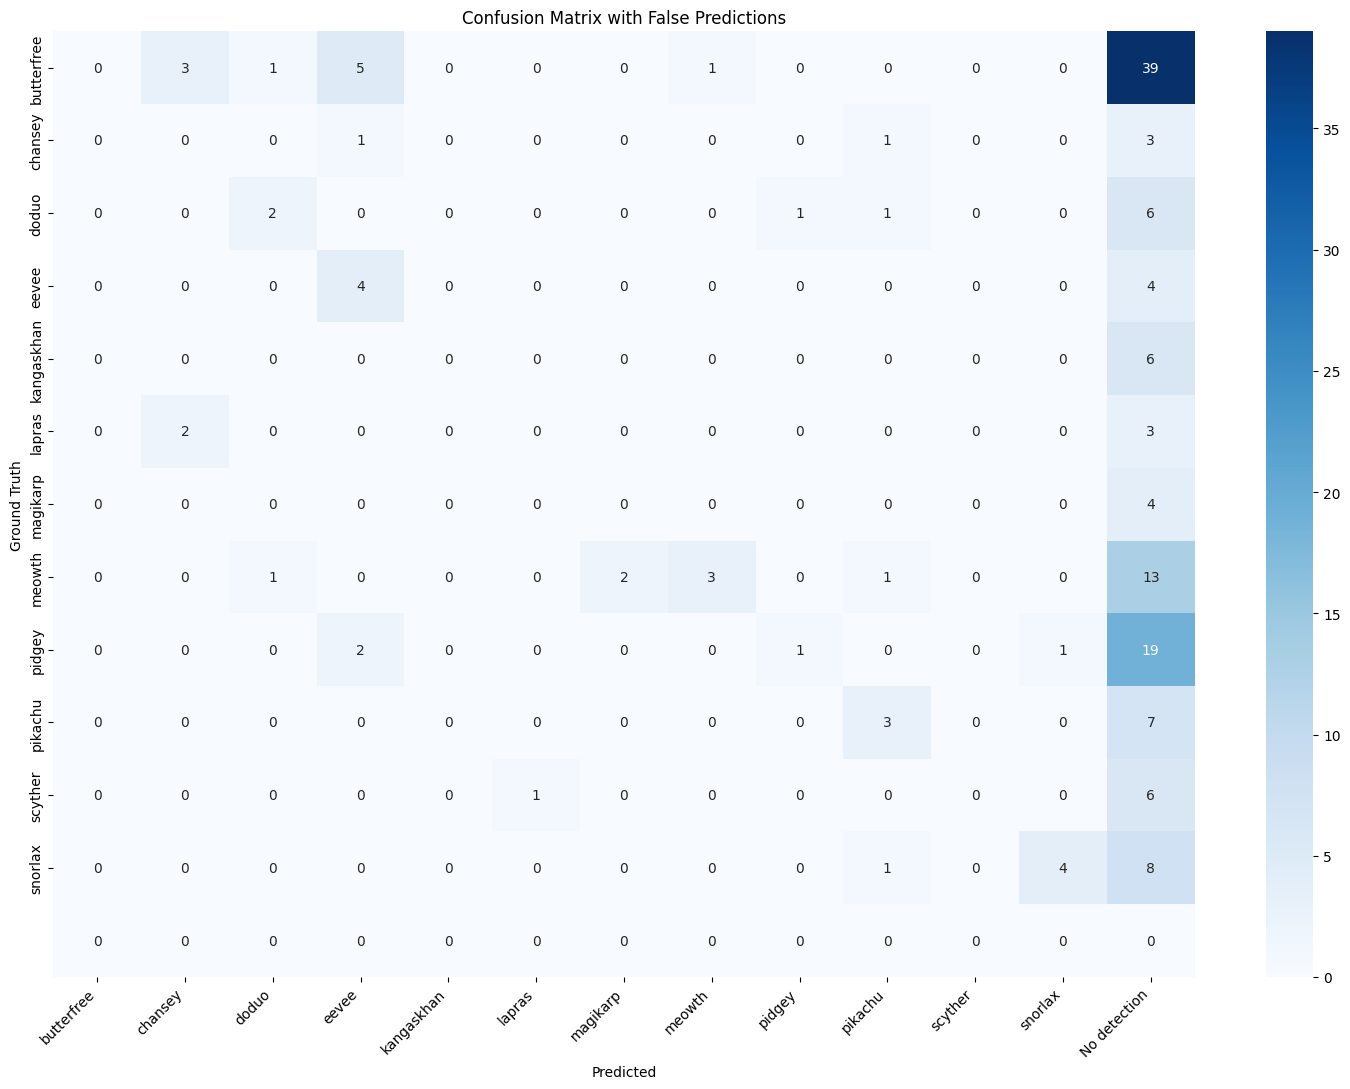

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(13)))

plt.figure(figsize=(15, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=names + ['No detection'],
    yticklabels=names,
    cmap='Blues'
)
plt.title('Confusion Matrix with False Predictions')
plt.ylabel('Ground Truth')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS-7643/confusion_matrix_full.png', dpi=150)
plt.show()

[0, 0, 0, 11, 7, 0, 11, 11, 9, 1, 7, 9, 7, 9, 2, 8, 8, 8, 2, 0, 0, 8, 8, 0, 6, 7, 7, 0, 0, 11, 0, 11, 2, 7, 7, 9, 0, 9, 2, 0, 11, 0, 0, 10, 5, 0, 8, 8, 8, 7, 9, 2, 7, 7, 10, 8, 8, 8, 0, 2, 11, 0, 0, 0, 9, 11, 1, 3, 8, 8, 8, 7, 0, 0, 11, 0, 10, 2, 4, 5, 0, 4, 6, 11, 11, 0, 0, 9, 0, 8, 8, 2, 9, 6, 0, 2, 10, 0, 4, 0, 1, 3, 7, 0, 2, 9, 0, 10, 0, 11, 6, 3, 11, 0, 8, 8, 8, 4, 10, 7, 3, 1, 0, 0, 8, 7, 0, 4, 0, 0, 7, 7, 7, 0, 0, 8, 7, 0, 8, 10, 3, 0, 7, 3, 1, 0, 3, 0, 5, 8, 7, 4, 3, 5, 0, 0, 0, 0, 0, 5]
[-1, -1, -1, -1, -1, -1, -1, 11, -1, 1, 7, 9, -1, -1, 2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 9, -1, 7, -1, -1, -1, -1, -1, -1, -1, 11, -1, -1, -1, 9, 11, 1, 3, -1, -1, -1, -1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 2, -1, -1, -1, 2, -1, -1, -1, -1, 1, 3, -1, -1, -1, 9, -1, -1, -1, -1, -1, -1, -1, -1, 8, -1, -1, -1, -1, 7, -1, -1, -1, -1, -1, 7, -1, -1, -1, -

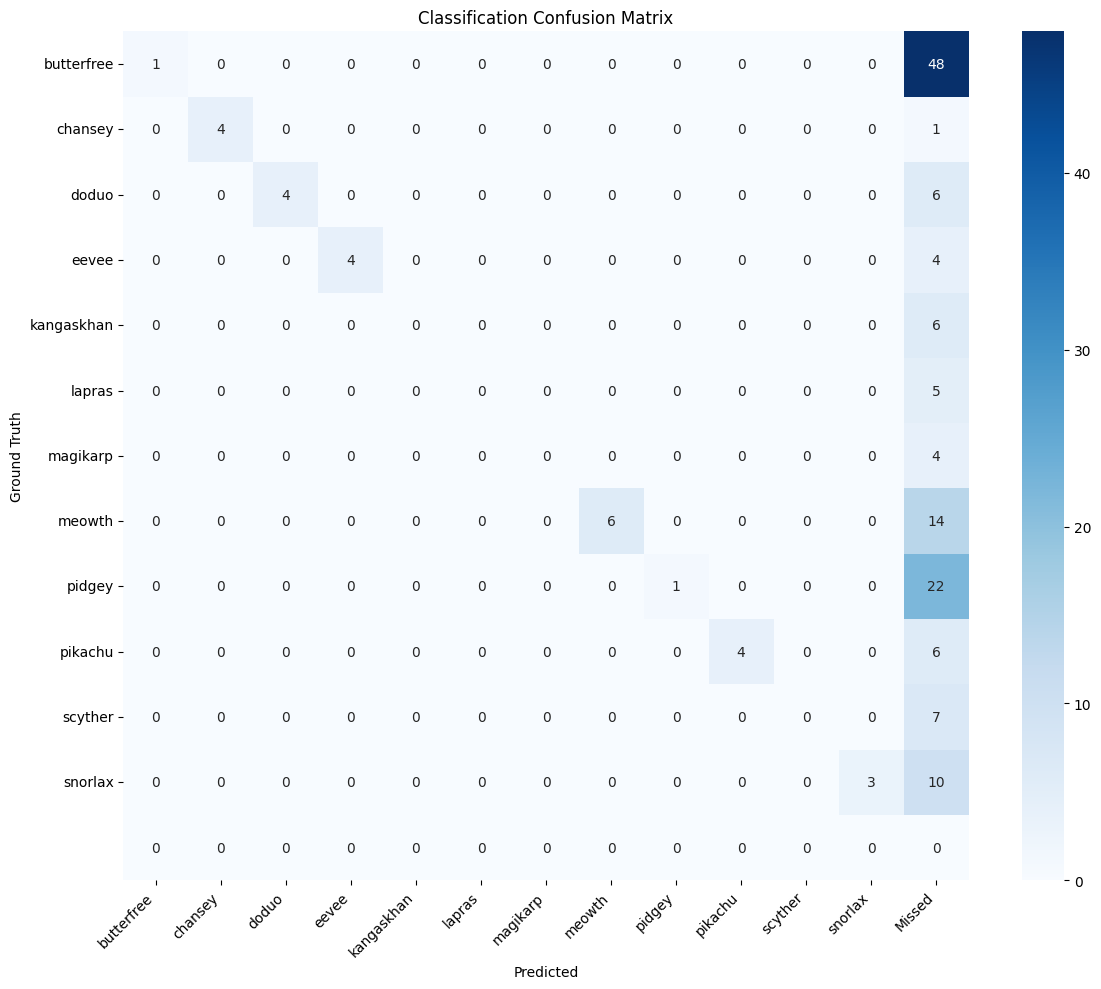

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

valid = [(t, p) for t, p in zip(y_true, y_pred) if p != -1]
y_true_valid = [t for t, p in valid]
y_pred_valid = [p for t, p in valid]

print(y_true)
print(y_pred)


print(classification_report(
    y_true_valid,
    y_pred_valid,
    labels=list(range(12)),
    target_names=names,
    zero_division=0
))

y_pred_display = [p if p != -1 else 12 for p in y_pred]


cm = confusion_matrix(y_true, y_pred_display, labels=list(range(13)))

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=names + ['Missed'],
    yticklabels=names,
    cmap='Blues'
)
plt.title('Classification Confusion Matrix')
plt.ylabel('Ground Truth')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS-7643/confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
from collections import defaultdict

missed = defaultdict(int)
total  = defaultdict(int)

for t, p in zip(y_true, y_pred):
    total[t] += 1
    if p == -1:
        missed[t] += 1

print(f"\n{'Class':<15} {'Total':<8} {'Missed':<8} {'Miss Rate':<10}")
print("-" * 45)
for i, name in enumerate(names):
    t = total[i]
    m = missed[i]
    rate = m / t if t > 0 else 0
    print(f"{name:<15} {t:<8} {m:<8} {rate:.1%}")


Class           Total    Missed   Miss Rate 
---------------------------------------------
butterfree      49       48       98.0%
chansey         5        1        20.0%
doduo           10       6        60.0%
eevee           8        4        50.0%
kangaskhan      6        6        100.0%
lapras          5        5        100.0%
magikarp        4        4        100.0%
meowth          20       14       70.0%
pidgey          23       22       95.7%
pikachu         10       6        60.0%
scyther         7        7        100.0%
snorlax         13       10       76.9%
